**часть 1 исследование многомерного нормального распределения**

1.1 генерация данных с заданной ковариацией

Теоретическая матрица:  [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]
выборочная ковариационная матрица:  [[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]
все проверки пройдены успешно


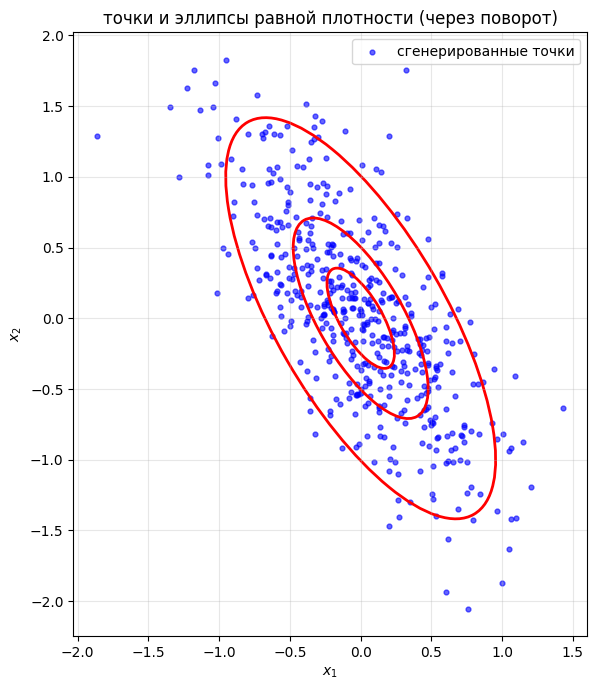

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import scipy.stats as stats

#параметры
M=500 #сколько точек генерируем
sigma1=0.3
sigma2=0.8
alpha=np.radians(30)

#матрица поворота(поворот вектора на угол альфа против часовой)
R=np.array([[np.cos(alpha), -np.sin(alpha)], [np.sin(alpha), np.cos(alpha)]])

#диагональная матрица ковариаций
D=np.diag([sigma1**2, sigma2**2])

#Теоретическая ковариационная матрица
#вычисляется по формуле из параметров
C_theor=R@D@R.T

print('Теоретическая матрица: ', C_theor)

#генерация независимых векторов
np.random.seed(42)#начальное состояние генрератора
#генерируем два массива случайных чисел из норм. распределения(колокол Гаусса)
x1=np.random.normal(0, sigma1, M)
x2=np.random.normal(0, sigma2, M)
#колокол центрирован в нуле
#тандартное отклонение
#сколько гененрировать

#объединяем в матрицу (М, 2) и применяем поворот
X_indep=np.column_stack([x1, x2])#склеиваем как столбцы новой матрицы
X= X_indep @ R.T#применяем поворот ко всем точкам

#выборочная ковариационная матрица
#вычисляется из сгенерированных данных
C_sample=np.cov(X.T)
#np.cov ожидает, что столбцы — это признаки, а строки — наблюдения. У нас X имеет форму (M,2) — то есть строки это наблюдения, столбцы — признаки. Казалось бы, подходит? Но нет — np.cov по умолчанию считает, что каждая строка — это отдельная переменная, а столбцы — наблюдения.
#Поэтому мы передаём X.T формы (2,M): две переменные, M наблюдений.
print('выборочная ковариационная матрица: ', C_sample)

#автопроверка
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
print('все проверки пройдены успешно')

#визуализация
def draw_ellipses(ax, cov, color, label): #Рисует 3 эллипса (0.5σ, 1σ, 2σ) для ковариации cov
  vals, vecs = np.linalg.eigh(cov)
  #np.linalg.eigh(cov) - функция линейной алгебры, которая для симметричной матрицы находит собственные числа (vals) и собственные векторы (vecs).
  angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))#находим угол наклона главной оси эллипса относительно горизонтали.
  #np.arctan2(y, x) — арктангенс с учётом четверти
  for n_std in (0.5, 1, 2):#Цикл по трём уровням: 0.5σ, 1σ, 2σ, на каждом уровне рисуем отдельный эллипс.
    w, h = 2 * n_std * np.sqrt(vals)#высота ширина эллипса
    '''
    Вычисляем ширину и высоту эллипса.
    np.sqrt(vals) — стандартные отклонения вдоль главных осей (это полуоси единичного 1σ-эллипса).
    n_std — множитель (0.5, 1 или 2)
    2 * ... — потому что Ellipse в matplotlib принимает полную ширину и высоту, а не полуоси.
    '''
    ax.add_patch(Ellipse((0, 0), w, h, angle=angle, fill=False, edgecolor=color, linewidth=2))#создаем объект эллипса
    '''
    центр — в точке (0, 0),
    ширина w, высота h,
    поворот на angle градусов.
    fill=False — не заливать внутренность, только контур.
    edgecolor=color — цвет контура.
    linewidth=2 — толщина линии.
    ax.add_patch(...) — добавляем этот эллипс на координатную плоскость ax.
    '''

#визуализация 1: точки и эллипсы теор распределения
fig, ax = plt.subplots(figsize=(7, 7))#создаем холст и оси

ax.scatter(X[:, 0], X[:, 1], s=12, alpha=0.6, color='blue', label='сгенерированные точки')
#рисуем диаграмму рассеяния, пару (x,y) отображает точкой на плоскости
'''
X[:, 0] все строки, столбец 0
s=12 размер точек
alpha делает точки полу прозрачными
'''

draw_ellipses(ax, C_theor, color='red', label='теория (0.5σ, 1σ, 2σ)')
#рисуем эллипсы
ax.set_aspect('equal')#одинаковый масштаб на 2 осях
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')#подписи осей
ax.set_title('точки и эллипсы равной плотности (через поворот)')
ax.legend()
ax.grid(alpha=0.3)#включает полупрозрачную сетку
plt.tight_layout()#автоматически подгоняет расположение эллементов
plt.show()




### 1.2 Сравнение с встроенной функцией


Форма X_builtin: (500, 2)
Ковариация X_builtin:
 [[ 0.22170343 -0.22536985]
 [-0.22536985  0.47626759]]


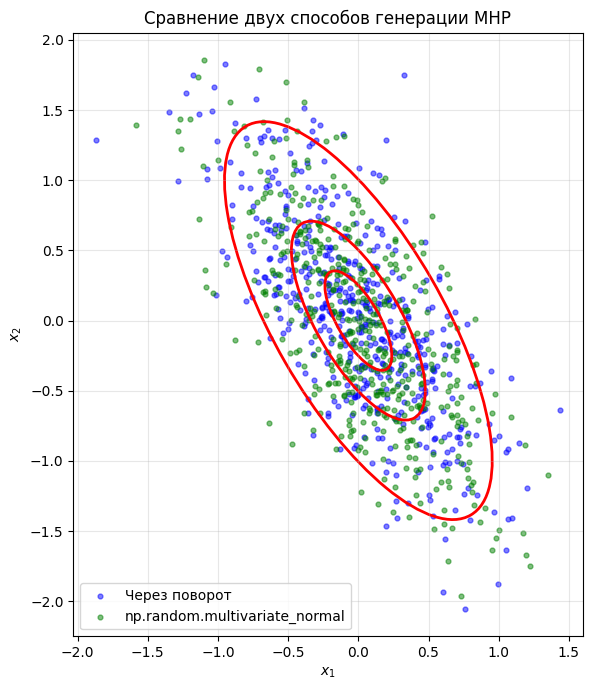

In [3]:
np.random.seed(0)#чтобы точки не совпали с предыдущими
X_builtin = np.random.multivariate_normal(mean=[0, 0], cov=C_theor, size=M)
'''
генегируем 500 точек с заданным средним и ковариацией
mean=[0, 0] — вектор средних. Двумерный, потому что мы в 2D-пространстве. [0, 0] означает
μ=(0,0)T — центр распределения в начале координат.
cov=C_theor — ковариационная матрица 2×2. Мы передаём теоретическую, которую вычислили в 1.1
Формат вывода — (500, 2)
'''
print('\nФорма X_builtin:', X_builtin.shape)
print('Ковариация X_builtin:\n', np.cov(X_builtin.T))

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(X[:, 0], X[:, 1],
           s=12, alpha=0.5, color='blue',
           label='Через поворот')

ax.scatter(X_builtin[:, 0], X_builtin[:, 1],
           s=12, alpha=0.5, color='green',
           label='np.random.multivariate_normal')

draw_ellipses(ax, C_theor, color='red', label='Теория (1σ)')

ax.set_aspect('equal')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Сравнение двух способов генерации МНР')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


1. совпадают ли облака визуально?

да, на графике видно, что синее и зеленое накладываются. У них один центр, одинаковый наклон, одинаковая вытянутость вдоль эллипсов. Оба облака накладываются на теоретические эллипсы. различаются только из-за отдельных точек, тк разные seed-ы, но их ковариации близки к теоретической

2.Почему встроенная функция может быть предпочтительнее?

Она короче и проще, универсальнее, тк работает для любой размерности, ручной только для 2д удобен,
она надежнее и с ней меньше шансов на ошибку, плюс быстрее, для больших выборок бкдет работать быстрее

**Часть 2. Визуализация плотности вероятности (5 баллов)**

mu_hat = [-0.01095388  0.02307548]
C_hat =
 [[ 0.23312293 -0.23625764]
 [-0.23625764  0.46568054]]
Форма grid_points: (10000, 2)
Форма pdf_scipy: (10000,)
Форма pdf_manual: (10000,)
Максимальная разница: 2.78e-16
Проверка пройдена


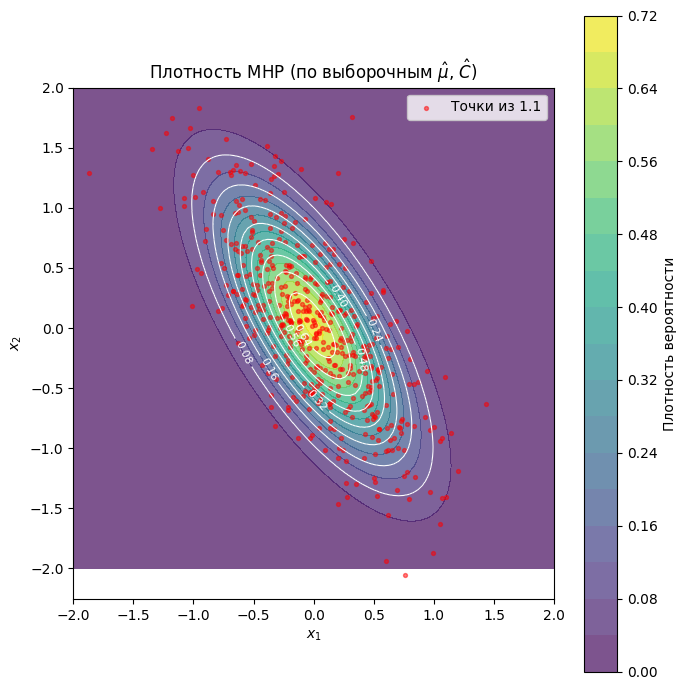

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

#шаг1. Оценка mu и C по данным из 1.1

# X-матрица (500, 2) из задания 1.1
mu_hat = np.mean(X, axis=0) #выборочное среднее (вектор из 2 чисел)
#усредняет по строкам
C_hat = np.cov(X.T) #выборочная ковариация (матрица 2x2)
#X.T-(2, 500)

print('mu_hat =', mu_hat)
print('C_hat =\n', C_hat)

#шаг2. Сетка точек от -2 до 2

#linspace(-2, 2, 100) — 100 равномерных точек от -2 до 2
x_grid = np.linspace(-2, 2, 100)
y_grid = np.linspace(-2, 2, 100)

#meshgrid создаёт 2D-сетку: XX[i,j], YY[i,j] — координаты точки (i,j)
#ПРЕВРАЩАЕТ ДВА ОДНОМЕРНЫХ МАССИВА В ДВЕ ДВУМЕР МАТРИЦЫ
XX, YY = np.meshgrid(x_grid, y_grid) #(100, 100) каждая строка попия _grid

# Собираем все точки сетки в матрицу точек(N, 2), где N = 100*100 = 10000
grid_points = np.column_stack([XX.ravel(), YY.ravel()])
'''
XX.ravel() — «выпрямляет» 2D-матрицу в 1D-массив, обходя её по строкам.
np.column_stack([a, b]) — склеивает два одномерных массива в столбцы матрицы.
'''
print('Форма grid_points:', grid_points.shape)   # (10000, 2)

#шаг3. Вычисление PDF двумя способами

# Способ 1: scipy, у него внутри та формула с экспонентой
mvn = multivariate_normal(mean=mu_hat, cov=C_hat)#объект распределения
pdf_scipy = mvn.pdf(grid_points)#вычисляем плотность в каждой точке, получаем набор
print('Форма pdf_scipy:', pdf_scipy.shape)   # (10000,)

# Способ 2: вручную
def manual_pdf(points, mu, C):
    """
    Ручное вычисление PDF многомерного нормального распределения.
    points: (N, d) — точки
    mu:     (d,)   — среднее
    C:      (d, d) — ковариационная матрица
    """
    d = len(mu)# размерность (2), нужно для (pi)^(d/2)
    #points имеет форму (1000, 2), значит points.shape[0]
    N = points.shape[0]# число точек (10000)

    #Определитель и обратная матрица

    det_C = np.linalg.det(C)#нужен для нормировочного коэф.
    #чем шире распределение тем больше определитель
    inv_C = np.linalg.inv(C)#нужна для квадратичной формы

    # Нормировочный коэффициент: 1 / ((2π)^(d/2) * sqrt(det C))
    norm_const = 1.0 / ((2 * np.pi) ** (d / 2) * np.sqrt(det_C))

    # Отклонения точек от среднего: (N, d)
    diff = points - mu#mu вычитается из каждой строки

    # Квадратичная форма (x-μ)^T C^{-1} (x-μ) для каждой точки
    # einsum: суммируем по индексам i, j
    quad_form = np.sum(diff @ inv_C * diff, axis=1)
    #axis это чтобы в каждой оси сложить числа и получить (1000, 1)
    # Итоговая плотность
    return norm_const * np.exp(-0.5 * quad_form)

pdf_manual = manual_pdf(grid_points, mu_hat, C_hat)
print('Форма pdf_manual:', pdf_manual.shape)   # (10000,)

#шаг4. Проверка совпадения

max_diff = np.max(np.abs(pdf_manual - pdf_scipy))
print(f'Максимальная разница: {max_diff:.2e}')
'''
.2 — 2 знака после запятой,
e — экспоненциальная запись (например, 1.23e-15).
Зачем e: числа очень маленькие (1e-15), обычная запись была бы неудобной (0.000000000000001).
'''

assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), \
       "Ручное вычисление отличается от scipy"
print('Проверка пройдена')

# ВИЗУАЛИЗАЦИЯ
# Преобразуем плоские массивы PDF обратно в 2D-сетку (100, 100)
ZZ_scipy = pdf_scipy.reshape(XX.shape)
#pdf_scipy.reshape((100, 100)) — возвращает матрицу (100, 100), заполняя её по строкам в том же порядке, в каком данные были «выпрямлены» через ravel().

fig, ax = plt.subplots(figsize=(7, 7))

#1. Залитый contour plot ---
# contourf рисует уровни плотности с заливкой
#метод осей, рисующий контурные области с заливкой.
cf = ax.contourf(XX, YY, ZZ_scipy,
                 levels=20, # число уровней
                 cmap='viridis',# цветовая карта
                 alpha=0.7) # прозрачность фона
#XX, YY — 2D-матрицы координат сетки. contourf использует их, чтобы понять, где рисовать.
#ZZ_scipy — 2D-матрица значений плотности. Определяет цвет в каждой точке.
#levels=20 — 20 уровней. Диапазон от min(ZZ) до max(ZZ) разбивается на 20 подинтервалов. Каждому — свой цвет.

#добавим цветовую шкалу справа, показывающую соответствие цветов числам
plt.colorbar(cf, ax=ax, label='Плотность вероятности')
'''
cf — объект из contourf, из которого берутся уровни и цвета.
ax=ax — на какой оси (рядом с какой) разместить шкалу.
label='Плотность вероятности' — подпись под шкалой.
'''
#2. Линии уровня с подписями ---
# contour рисует линии уровня поверх заливки
cs = ax.contour(XX, YY, ZZ_scipy,
                levels=10,
                colors='white',
                linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')   # подписи значений на линиях
#clabel это метод для добавления подписей

#3. Исходные точки поверх
ax.scatter(X[:, 0], X[:, 1],
           s=8, alpha=0.5, color='red', label='Точки из 1.1')
#накладываем исходные 500 точек поверх фона

#Оформление
ax.set_aspect('equal')#одинаковый мастаб по двум осям
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Плотность МНР (по выборочным $\\hat{\\mu}$, $\\hat{C}$)')
ax.legend(loc='upper right')
plt.tight_layout()#подгоняет отсту
plt.show()

**Часть 3. Бинарная классификация через байесовский подход**

p(y=0) = 0.5, p(y=1) = 0.5


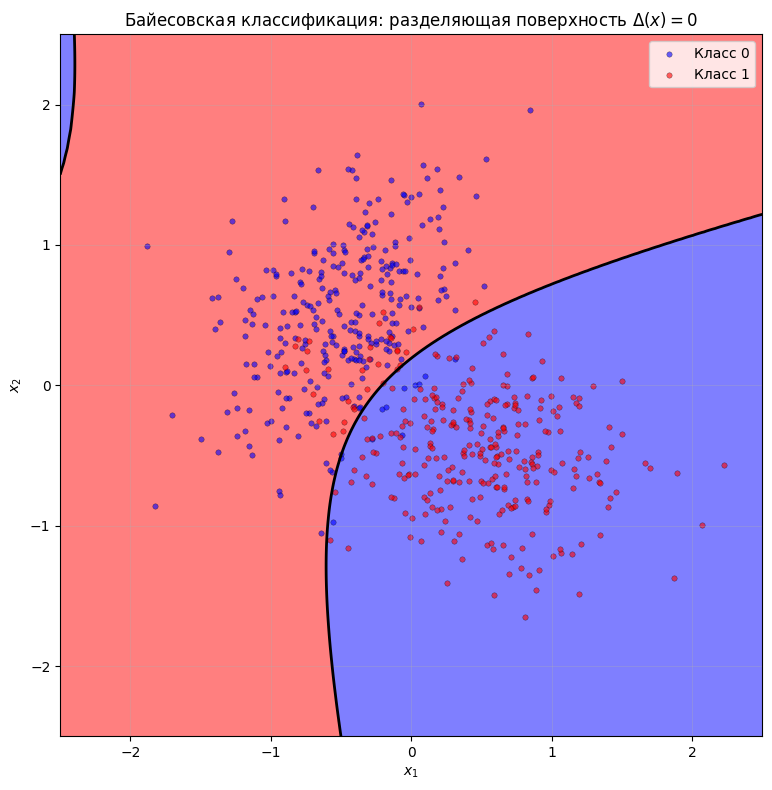

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 3.1 ГЕНЕРАЦИЯ ДАТАСЕТА

np.random.seed(42)

#параметры классов
mu0 = np.array([-0.5, 0.5])#центр класса 0
C0 = np.array([[0.2, 0.1],
               [0.1, 0.3]])#ковар матрица класса 0

mu1 = np.array([0.5, -0.5])#центр класса 1
C1 = np.array([[0.3, -0.1],
               [-0.1, 0.2]])#ковар матрица класса 1

#С0!=С1 следовательно граница будет квадратичной

M = 300#количество точек в каждом классе

# Генерируем точки для каждого класса
X0 = np.random.multivariate_normal(mu0, C0, M)# (300, 2)
X1 = np.random.multivariate_normal(mu1, C1, M)# (300, 2)
#Результат: матрица формы (300, 2). Каждая строка — точка (x1,x2), сгенерированная из N(μ0,C0).

# Собираем все точки в одну матрицу (для удобства)
X_all = np.vstack([X0, X1])# (600, 2) склеиваем по вертикали

# Априорные вероятности: доли классов в выборке
p0 = M / (2 * M)# = 0.5
p1 = M / (2 * M)# = 0.5
print(f'p(y=0) = {p0}, p(y=1) = {p1}')

# 3.2 СЕТКА И ВЫЧИСЛЕНИЕ Δ(x)

# Сетка от -2.5 до 2.5 (чуть шире, чем в Части 2 — центры сдвинуты)
x_grid = np.linspace(-2.5, 2.5, 200)#200 точек от -2.5 до 2.5, как в части2
y_grid = np.linspace(-2.5, 2.5, 200)#(200,)
#берем 200 точек а не 100, чтобы граница разделяющей поверхности была более гладкой
XX, YY = np.meshgrid(x_grid, y_grid)
#XX — каждая строка — это копия x_grid
#YY — каждый столбец — это копия y_grid
#XX[i, j] и YY[i, j] вместе дают точку с координатами (xj,yi)
#XX[0,0] = -2.5,  YY[0,0] = -2.5   →  точка (-2.5, -2.5)
# XX YY (200, 200)
grid_points = np.column_stack([XX.ravel(), YY.ravel()])# (40000, 2)-400 точек 2 координаты
#ravel — «выпрямляет» 2D-матрицу в 1D-массив, обходя её по строкам.
#XX.ravel()[0] и YY.ravel()[0] — координаты одной точки (40000,)
#np.column_stack([...]) — склеиваем в матрицу точек, склеиваем массивы как столбцы
#multivariate_normal.pdf() ожидает матрицу (N, d) — по одной точке на строку.

# Создаём распределения для каждого класса
mvn0 = multivariate_normal(mean=mu0, cov=C0)
mvn1 = multivariate_normal(mean=mu1, cov=C1)

# PDF каждого класса в каждой точке сетки
pdf0 = mvn0.pdf(grid_points)# p(x | y=0),  (40000,)
pdf1 = mvn1.pdf(grid_points)# p(x | y=1),  (40000,)

# Функция Δ(x) = p(x|y=0)·p(y=0) − p(x|y=1)·p(y=1)
delta = pdf0 * p0 - pdf1 * p1
delta_2d = delta.reshape(XX.shape)#превращаем плоский массив в матрицу (200, 200) для contourf
#укладываем 40000 значений в матрицу 200*200 по строкам

# ВИЗУАЛИЗАЦИЯ

fig, ax = plt.subplots(figsize=(8, 8))

# 1. Заливка фона по знаку Δ
# Уровни: [-inf, 0, +inf] → две зоны: синяя (Δ<0) и красная (Δ>0)
# Используем contourf с двумя уровнями
#Рисуем залитый контурный график с двумя зонами.
levels_fill = [delta_2d.min(), 0, delta_2d.max()]
cf = ax.contourf(XX, YY, delta_2d,
                 levels=levels_fill,
                 colors=['blue', 'red'],
                 alpha=0.5)
#blue — Δ < 0 (класс 1), red — Δ > 0 (класс 0)
# Порядок цветов: первый уровень = между -inf и 0, второй = между 0 и +inf

#2. Разделяющая поверхность: Δ(x) = 0
#рисуем линию уровня Δ = 0
ax.contour(XX, YY, delta_2d,
           levels=[0],# только один уровень — ноль
           colors='black',
           linewidths=2)

#3.Точки классов
#точки генерируем
ax.scatter(X0[:, 0], X0[:, 1],
           s=15, alpha=0.6, color='blue',
           edgecolor='k', linewidth=0.3, label='Класс 0')
ax.scatter(X1[:, 0], X1[:, 1],
           s=15, alpha=0.6, color='red',
           edgecolor='k', linewidth=0.3, label='Класс 1')

# --- Оформление ---
ax.set_aspect('equal')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Байесовская классификация: разделяющая поверхность $\\Delta(x) = 0$')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Вопрос (ответить текстом): является ли разделяющая поверхность линейной? Почему?

разделяющая поверхность не является линейной, она квадратична. это изза того, что у нас ковариационные матрицы различны. уравнение границы дельта=0 после логарифмирования и подстановки PDF МНР содержит квадратичный член с разностью обратных ковариационных матриц, если бы матрицы были равны, квадратичный член исчез, и граница стала бы линейной LDA, а в нашем случае матрицы различны, поэтому границв квадратичная кривая QDA.

**Часть 4. Линейный дискриминантный анализ (LDA)**


4.1 Теоретический вывод (в тетради)
Задание: выведите явное выражение для разделяющей поверхности в случае, когда  C0=C1=C . Покажите, что она линейна. Напишите формулу для весов  w  и порога  b  в уравнении  wTx+b=0 .

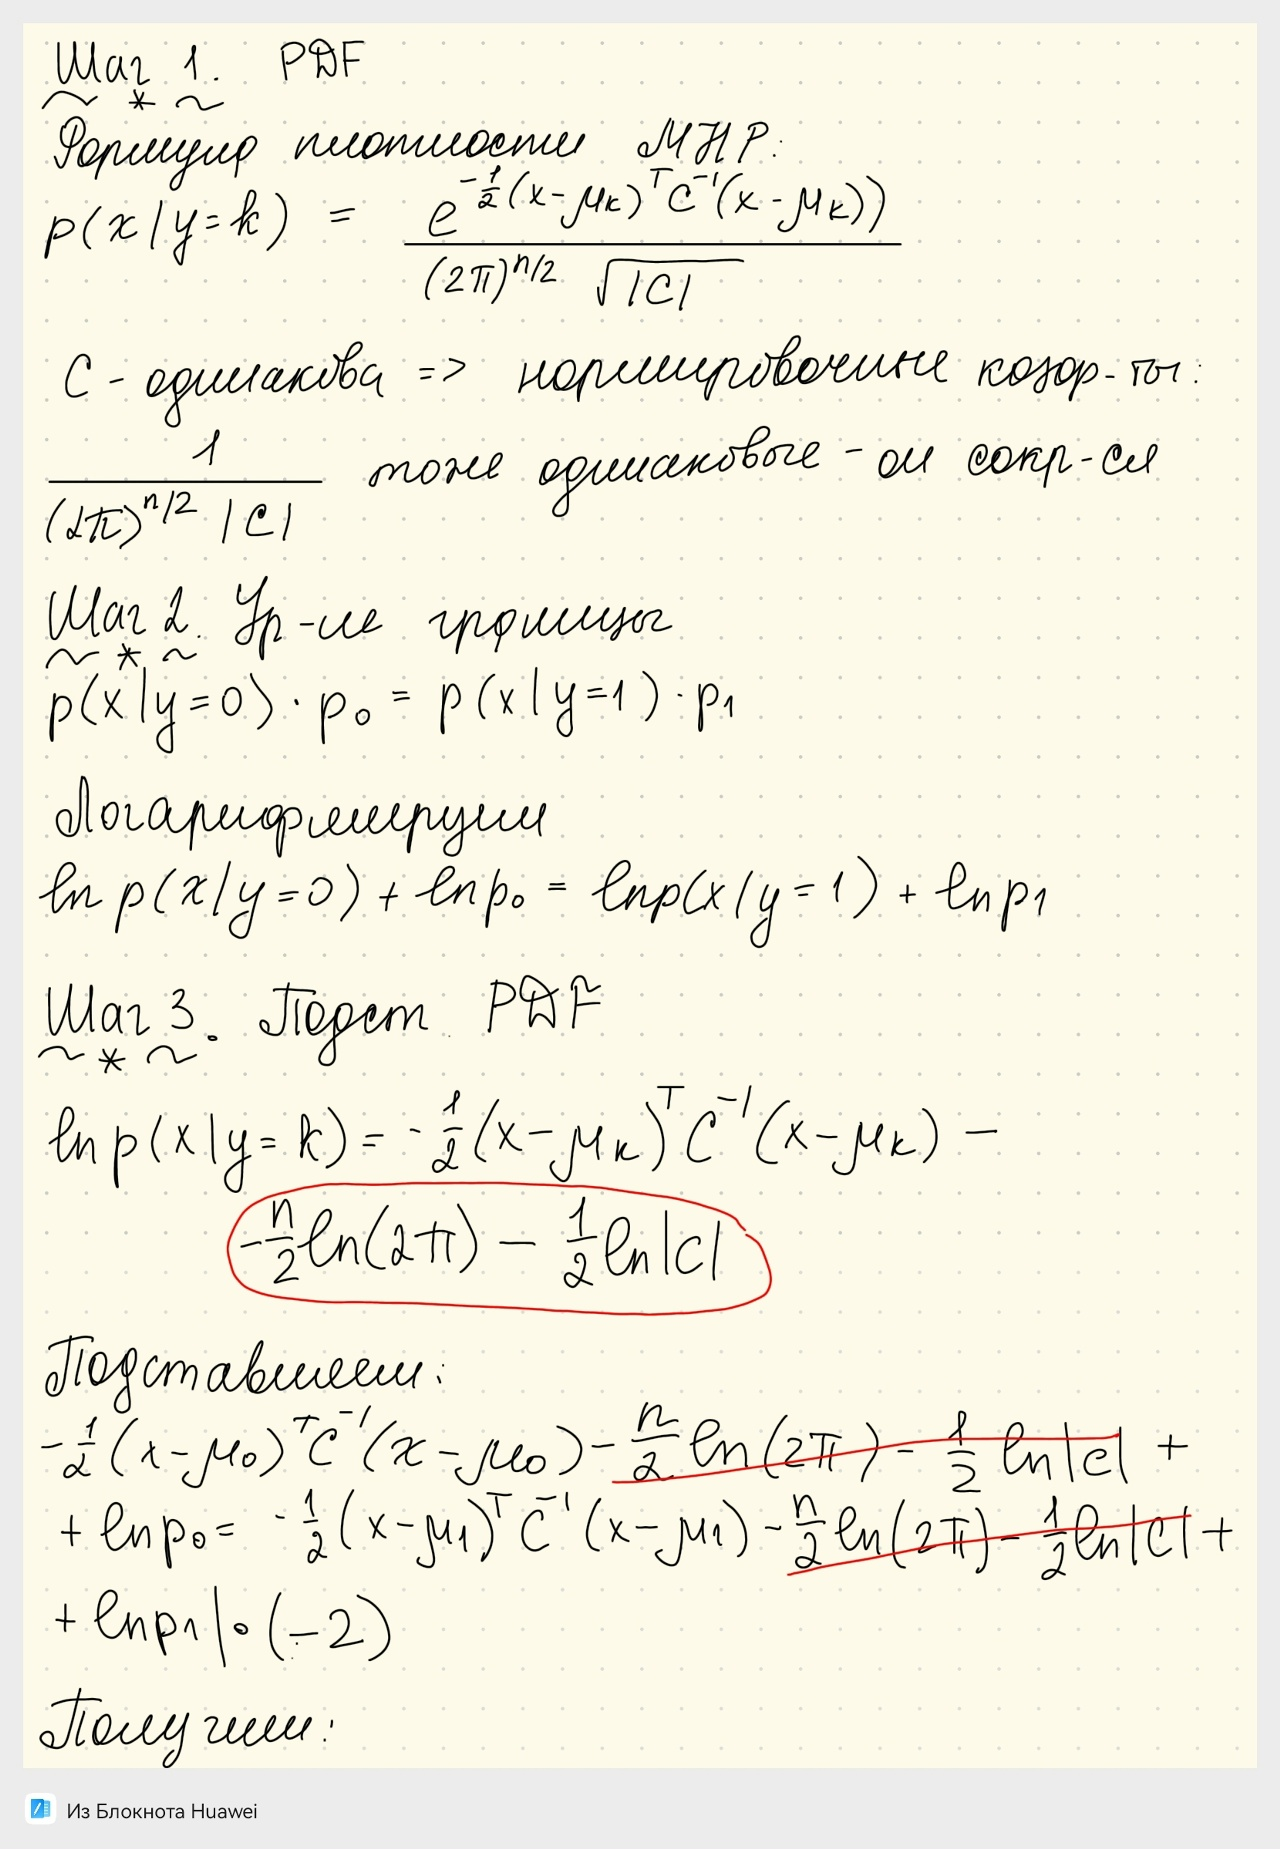

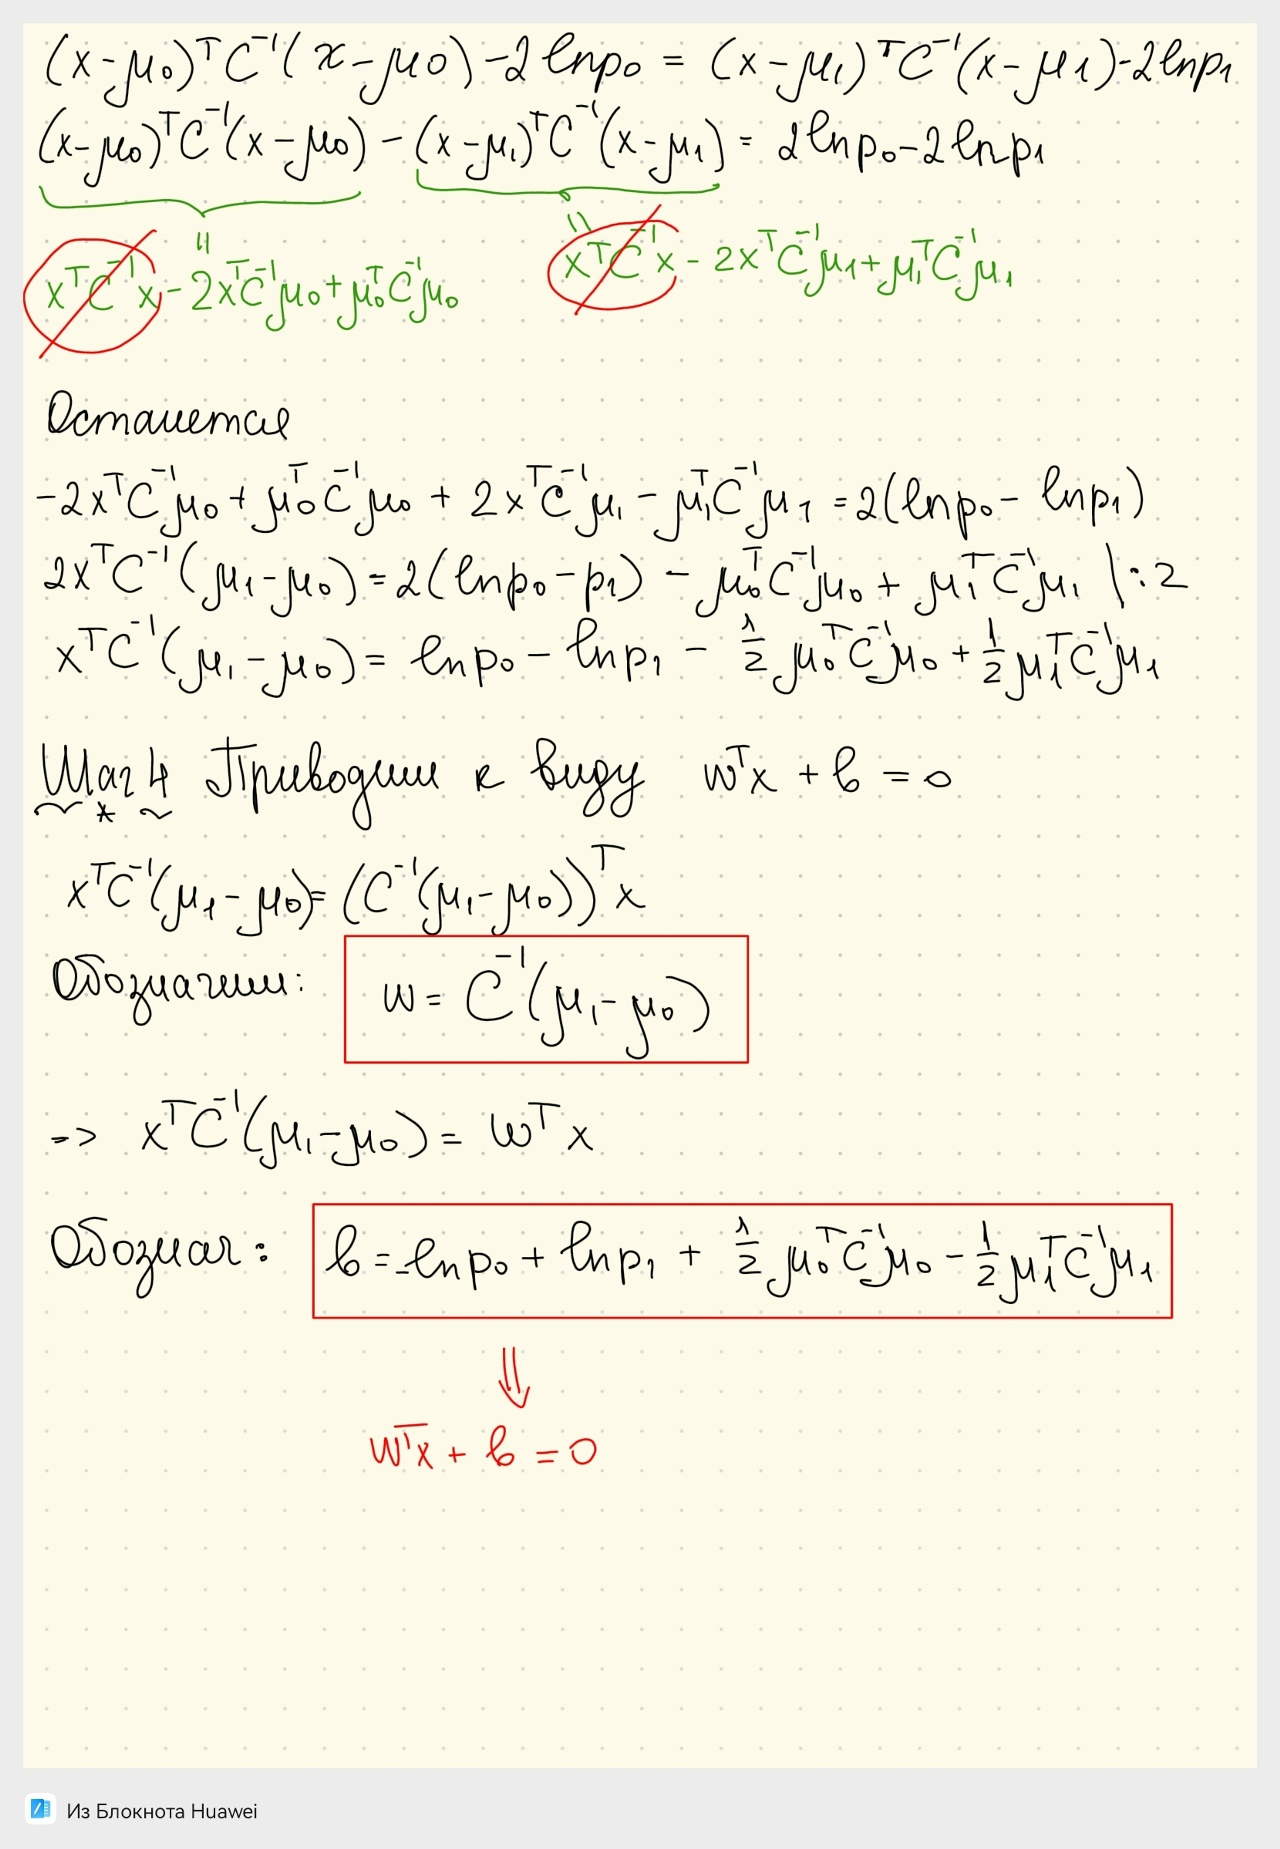

4.2 Реализация класса LDA

In [6]:
from sklearn.base import BaseEstimator
import numpy as np
import matplotlib.pyplot as plt


class MyLDA(BaseEstimator):#объявляем класс, наследуемый от BaseEstimator
    """
    Линейный дискриминантный анализ (LDA) для двух классов.
    Предполагает одинаковую ковариацию у обоих классов.
    """

    def __init__(self):#конструктор, через self(ссылка на объект) обращемся к атрибутам и методам объекта
        self.classes_ = None#массив уникальных классов
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b

    def fit(self, X, y):#метод обучения модели на данных
        '''
        X — матрица признаков (n_samples, n_features),
        y — вектор меток (n_samples,).
        '''
        X = np.asarray(X)#приводим входные данные к numpy-массивам
        y = np.asarray(y)
        n_samples, n_features = X.shape
        '''
        n_samples — число точек,
        n_features — число признаков (у нас 2)
        '''

        # 1. Уникальные классы
        self.classes_ = np.unique(y)
        #np.unique(y) возвращает отсортированный массив уникальных значений.

        # 2. Средние и априорные
        self.means_ = {}#пустые словари
        self.priors_ = {}
        for c in self.classes_:#цикл по уникальным классам
            X_c = X[y == c]#булева маска и булева индексация
            self.means_[c] = X_c.mean(axis=0)#усредняем вдоль оси 0 для каждого признака
            self.priors_[c] = len(X_c) / n_samples
            #Априорная вероятность класса c — доля точек класса в выборке.

        # 3. Общая ковариация (усреднённая по классам)
        cov = np.zeros((n_features, n_features))#создаем нулевую матрицу
        for c in self.classes_:
            X_c = X[y == c]#выбор точек класса с
            diff = X_c - self.means_[c]#центрируем точки класса с
            cov += diff.T @ diff#накапливаем сумму квадратов отклонений
        cov /= (n_samples - len(self.classes_))#дает несмещенную оценку

        # 4. Регуляризация
        cov_reg = cov + 1e-6 * np.eye(n_features)#сделали матрицу обратимой
        self.cov_ = cov_reg#сохраняем в атрибуте

        # 5. w и b
        c0, c1 = self.classes_[0], self.classes_[1]#достаем два класса
        mu0, mu1 = self.means_[c0], self.means_[c1]
        p0, p1 = self.priors_[c0], self.priors_[c1]
        #достаем средние и априорные

        inv_cov = np.linalg.inv(cov_reg)#обратная ковариационная матрица

        # w без нормировки
        w = inv_cov @ (mu1 - mu0)

        # b без нормировки
        # b = -1/2 mu0^T C^{-1} mu0 + 1/2 mu1^T C^{-1} mu1 + log(p1/p0)
        b = (-0.5 * mu0 @ inv_cov @ mu0
             + 0.5 * mu1 @ inv_cov @ mu1
             + np.log(p1 / p0))

        # НОРМИРОВКА: ||w|| = 1 (как в sklearn)
        w_norm = np.linalg.norm(w)
        self.coef_ = w / w_norm
        self.intercept_ = b / w_norm

        return self

    def decision_function(self, X):#Метод, возвращающий значения wTx+b
        X = np.asarray(X)
        return X @ self.coef_ + self.intercept_

    def predict(self, X):#Метод, возвращающий предсказанные классы
        scores = self.decision_function(X)#Вычисляем wTx+b для всех точек.
        return np.where(scores > 0, self.classes_[1], self.classes_[0])
        #Поэлементный выбор класса.
        #np.where(condition, a, b) — где condition истинно → a, иначе → b.

    def predict_proba(self, X):
      #Метод, возвращающий вероятности принадлежности к каждому классу.
        scores = self.decision_function(X)#Вычисляем wTx+b.
        p1 = 1.0 / (1.0 + np.exp(-scores))
        p0 = 1.0 - p1
        #Почему именно сигмоида: для двух МНР с одинаковой ковариацией апостериорная вероятность имеет именно такую форму. Это следствие байесовского вывода.
        return np.column_stack([p0, p1])

4.3 Проверка на синтетике

In [7]:
np.random.seed(42)

# Общая ковариация
C = np.array([[1.0, 0.5],
              [0.5, 1.0]])

# Разные средние
mu0 = np.array([-1.0, -1.0])
mu1 = np.array([ 1.0,  1.0])

# Генерируем данные
N = 300
#точки
X0 = np.random.multivariate_normal(mu0, C, N)#(300, 2)
X1 = np.random.multivariate_normal(mu1, C, N)#(300, 2)

X = np.vstack([X0, X1])#(600, 2)
y = np.array([0] * N + [1] * N)#вектор меток (600,)

# Разделяем на train/test
#Импортируем функцию для разделения данных.
from sklearn.model_selection import train_test_split
#Разделяем данные на обучающую и тестовую выборки.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
'''
X, y — данные и метки, которые делим.
test_size=0.3 — 30% данных идут в тест, 70% — в обучение. То есть 420 точек в train, 180 в test.
random_state=42 — фиксирует случайность разделения. При том же seed разделение будет тем же.
stratify=y — стратификация. Сохраняет пропорции классов в train и test. У нас классы равны (50/50), значит и в train, и в test будет по 50% каждого.

X_train — признаки обучающей выборки, (420, 2),
X_test — признаки тестовой выборки, (180, 2),
y_train — метки обучающей, (420,),
y_test — метки тестовой, (180,).
'''

# Обучаем MyLDA и sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
#sklearn.discriminant_analysis — модуль с дискриминантным анализом.

my_lda = MyLDA().fit(X_train, y_train)#Создаём и обучаем наш MyLDA.
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
#sk_lda должен дать те же предсказания, что my_lda, если наша реализация корректна.

print('MyLDA:')
print('  coef_     =', my_lda.coef_)
print('  intercept_ =', my_lda.intercept_)
print('Sklearn:')
print('  coef_     =', sk_lda.coef_[0])
print('  intercept_ =', sk_lda.intercept_)

# --- Автопроверка ---
# Проверка сонаправленности: косинус угла между векторами = 1
cos_sim = (my_lda.coef_ @ sk_lda.coef_[0]) / (
    np.linalg.norm(my_lda.coef_) * np.linalg.norm(sk_lda.coef_[0])
)
assert np.abs(cos_sim - 1) < 1e-6, "Вектора весов не сонаправлены"

# Проверка предсказаний: доля совпадений > 0.98
match = (my_lda.predict(X_test) == sk_lda.predict(X_test)).mean()
assert match > 0.98, f"Предсказания совпадают только на {match:.2%}"


# --- Точность ---
acc_my = np.mean(my_lda.predict(X_test) == y_test)
acc_sk = np.mean(sk_lda.predict(X_test) == y_test)
print(f'Точность MyLDA:   {acc_my:.4f}')
print(f'Точность sklearn: {acc_sk:.4f}')

MyLDA:
  coef_     = [0.72364422 0.6901732 ]
  intercept_ = -0.050555112450628464
Sklearn:
  coef_     = [1.35158202 1.28906656]
  intercept_ = [0.094424]
Точность MyLDA:   0.8944
Точность sklearn: 0.8944


Визуализация

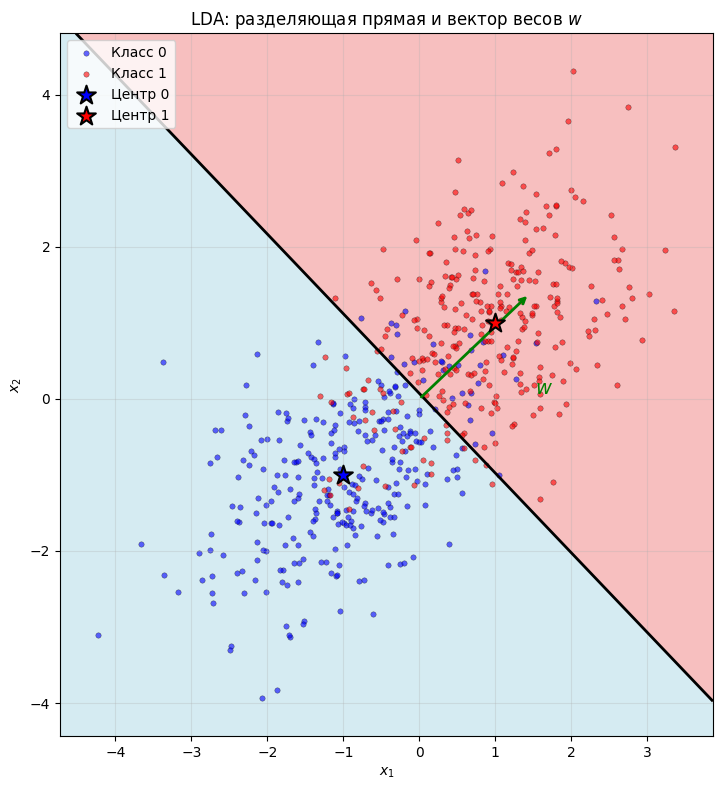

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

# --- Сетка ---
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])

# --- Значения decision_function ---
Z = my_lda.decision_function(grid).reshape(xx.shape)

# --- Заливка фона ---
ax.contourf(xx, yy, Z,
            levels=[Z.min(), 0, Z.max()],
            colors=['lightblue', 'lightcoral'],
            alpha=0.5)

# --- Разделяющая линия ---
ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)

# --- Точки ---
ax.scatter(X0[:, 0], X0[:, 1], s=15, alpha=0.6, color='blue',
           edgecolor='k', linewidth=0.3, label='Класс 0')
ax.scatter(X1[:, 0], X1[:, 1], s=15, alpha=0.6, color='red',
           edgecolor='k', linewidth=0.3, label='Класс 1')

# --- Центры классов ---
ax.scatter(*mu0, s=200, marker='*', color='blue',
           edgecolor='k', linewidth=1.5, zorder=5, label='Центр 0')
ax.scatter(*mu1, s=200, marker='*', color='red',
           edgecolor='k', linewidth=1.5, zorder=5, label='Центр 1')

# --- Вектор w ---
# Рисуем w как стрелку из начала координат
ax.annotate('', xy=my_lda.coef_ * 2, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(my_lda.coef_[0] * 2.1, my_lda.coef_[1] * .1, '$w$',
        color='green', fontsize=14, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('LDA: разделяющая прямая и вектор весов $w$')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Часть 5. Наивный байесовский классификатор (NB)**

5.1 Теоретическое обоснование
Вопрос: почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление  p(x|y) ?

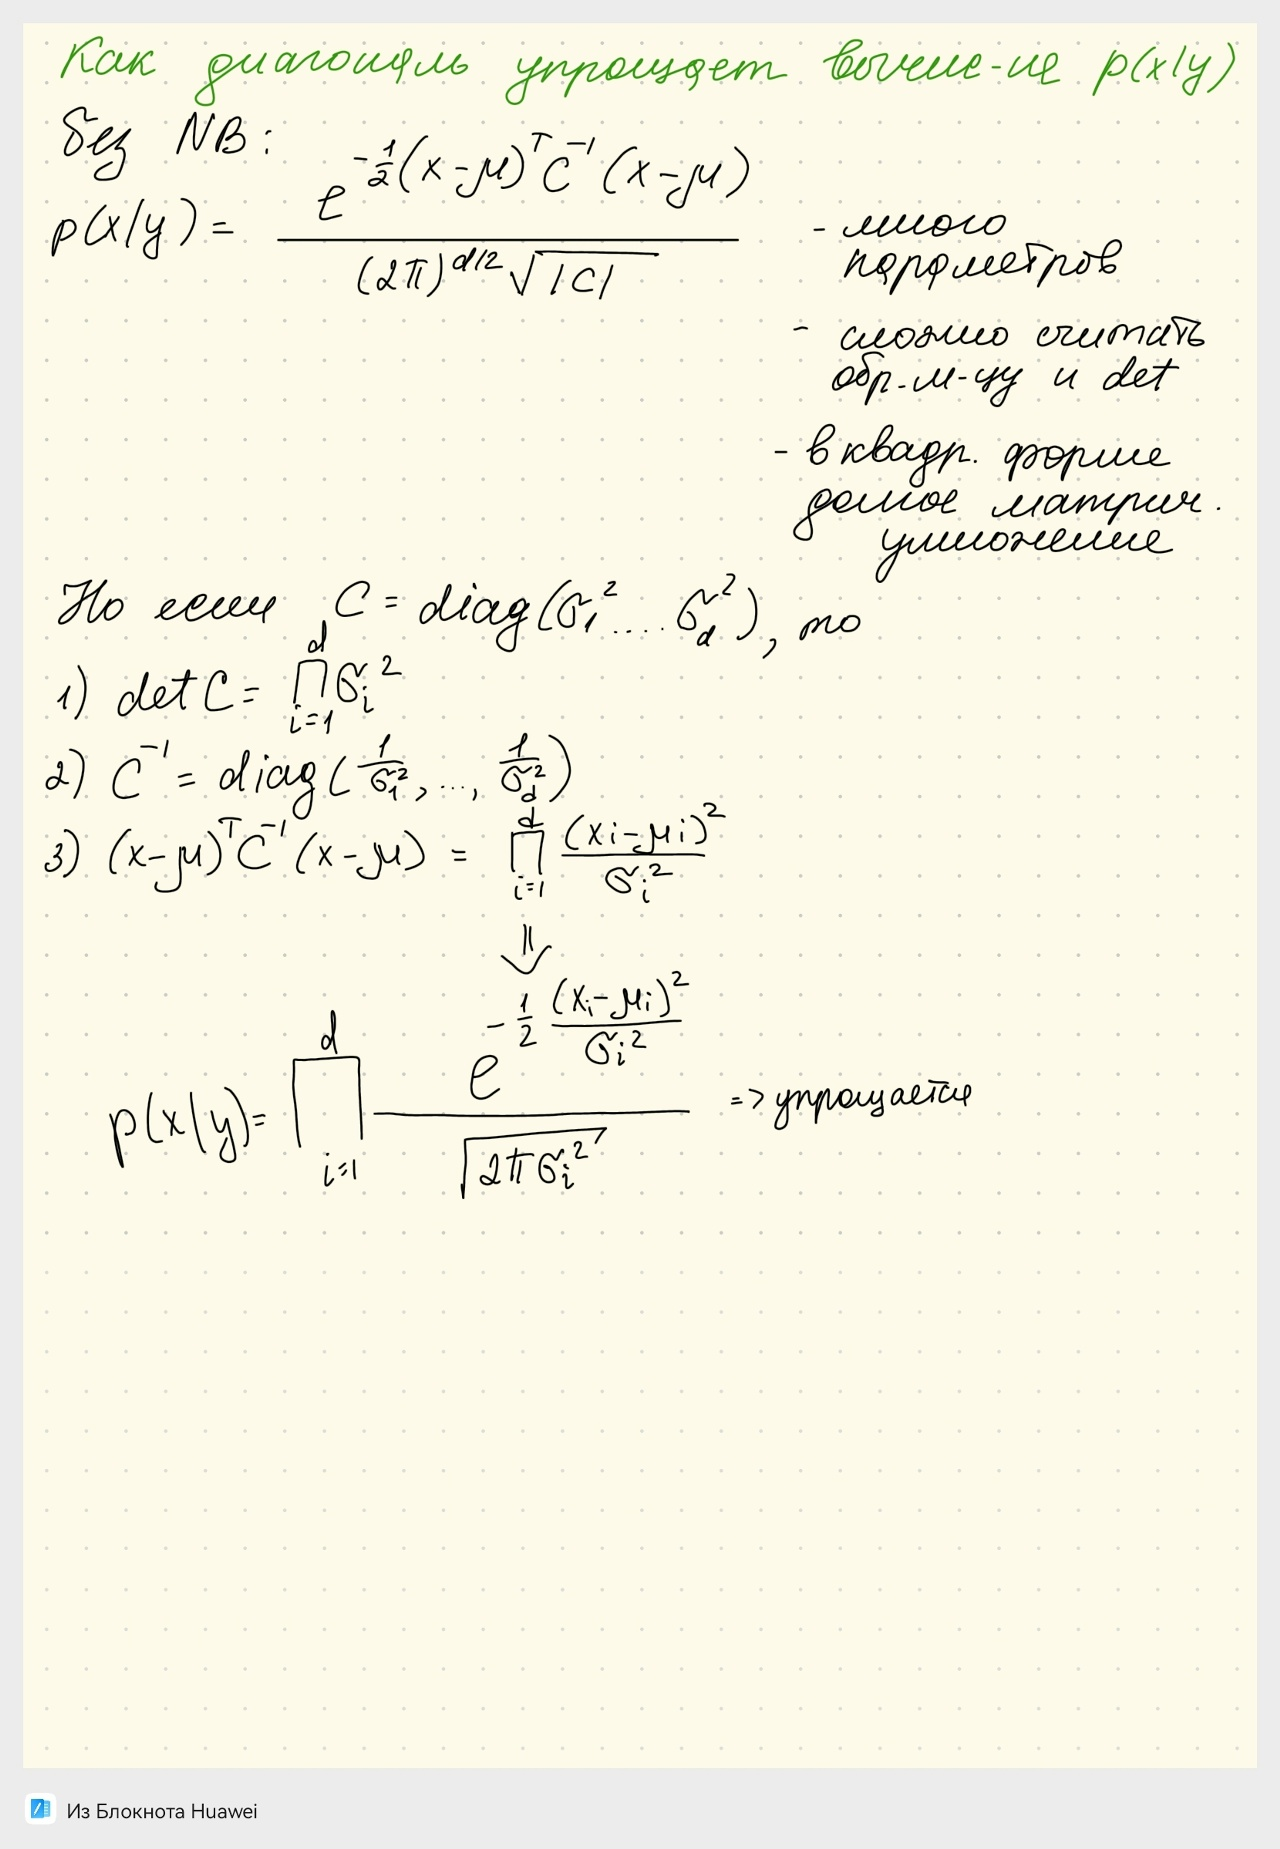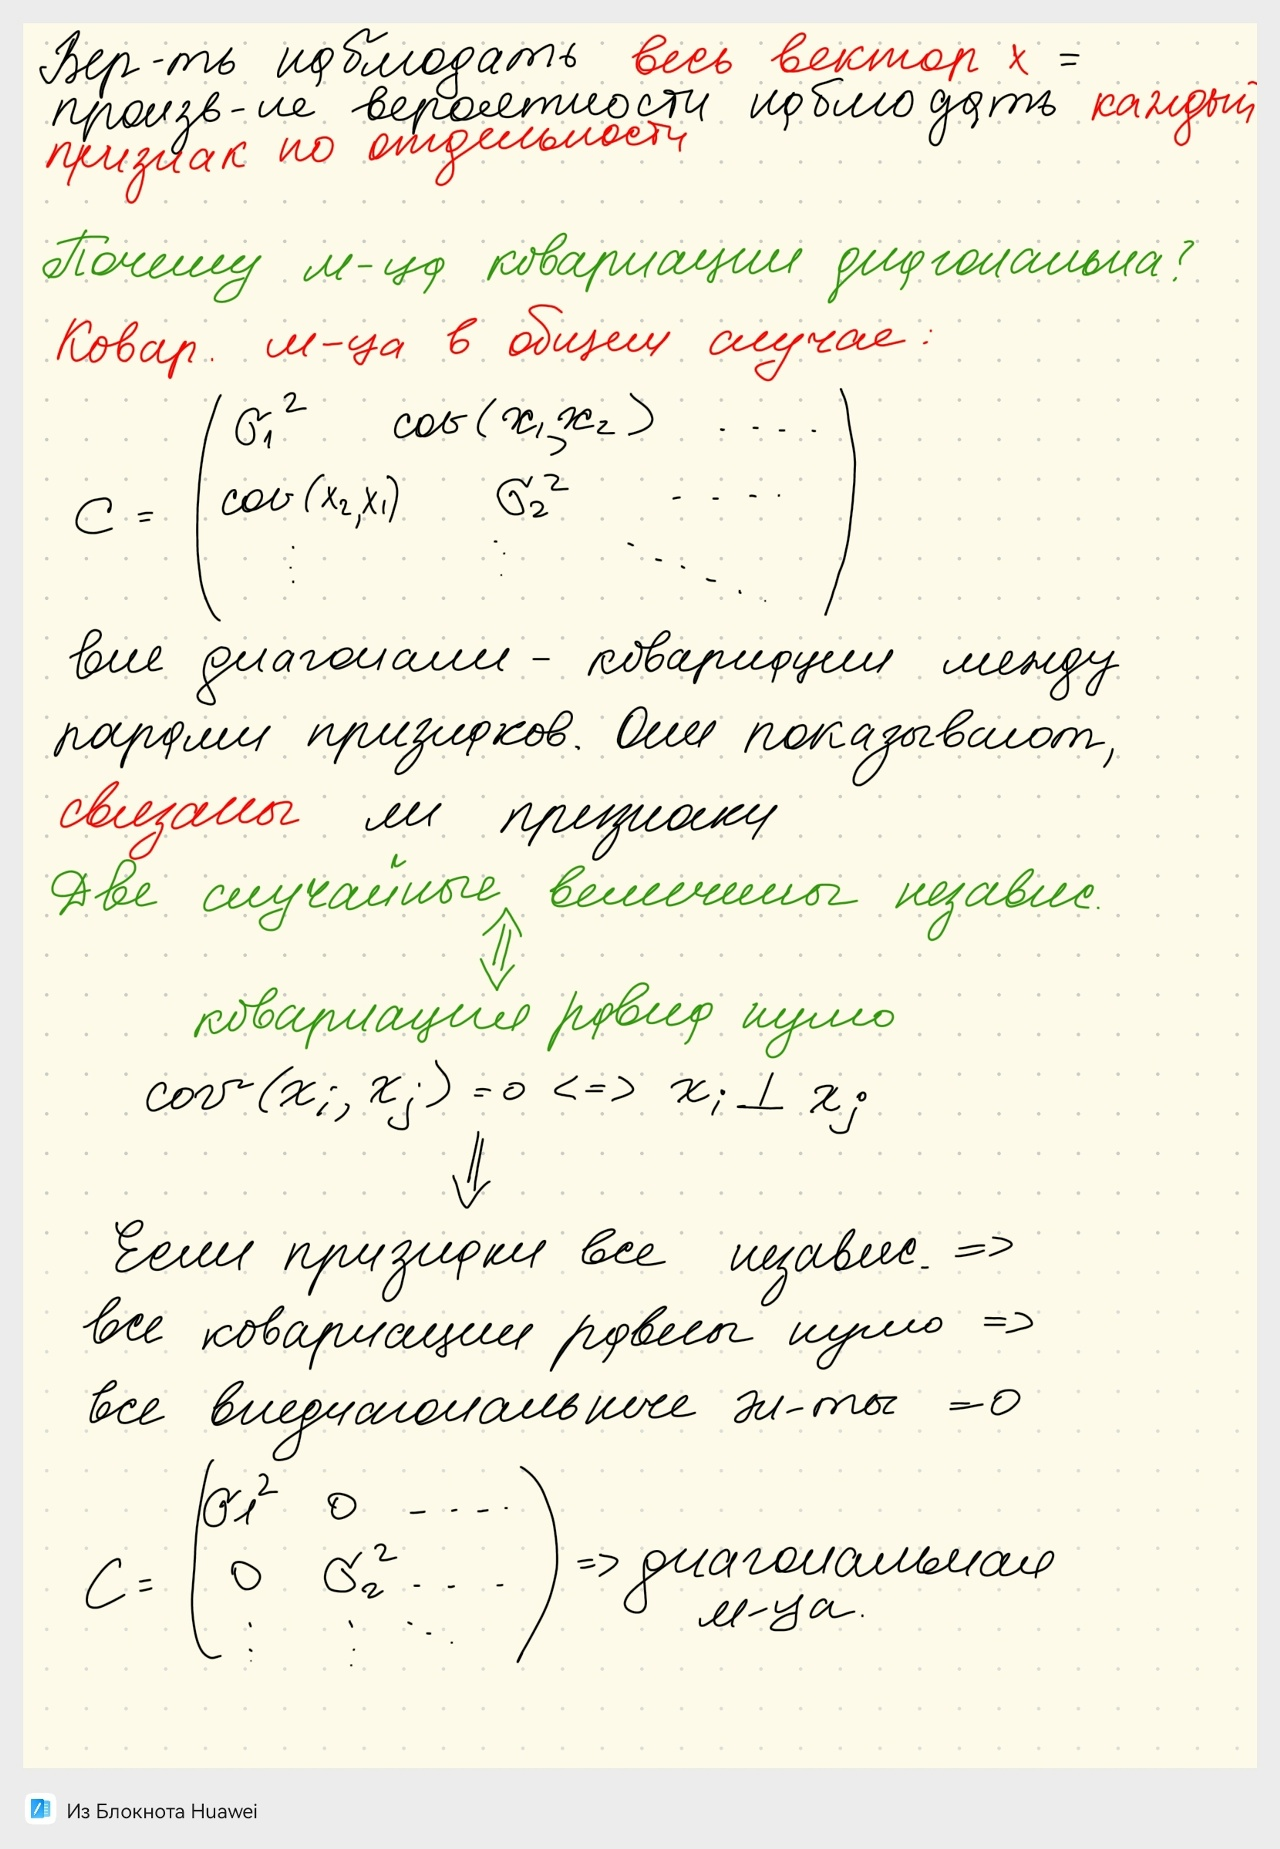

5.2 Реализация класса NB

In [9]:
from sklearn.base import BaseEstimator
import numpy as np

class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_=None
        self.means_=None
        self.vars_=None
        self.priors_=None

    def fit(self, X, y):
        X=np.asarray(X)
        y=np.asarray(y)
        n_samples, n_features=X.shape
        self.classes_=np.unique(y)

        self.means_={}
        self.vars_={}
        self.priors_={}

        for c in self.classes_:
            Xc=X[y==c]
            self.means_[c]=Xc.mean(axis=0)
            self.vars_[c]=Xc.var(axis=0)+1e-9   #сглаживание как у sklearn
            self.priors_[c]=len(Xc)/n_samples

        return self

    def _log_likelihood(self, X, c):
        mu=self.means_[c]
        var=self.vars_[c]
        #логарифм правдоподобия гауссова NB: сумма по признакам
        log_p=-0.5*np.sum(np.log(2*np.pi*var)+(X-mu)**2/var, axis=1)
        return log_p+np.log(self.priors_[c])

    def predict(self, X):
        X=np.asarray(X)
        scores=np.column_stack([self._log_likelihood(X, c) for c in self.classes_])
        return self.classes_[np.argmax(scores, axis=1)]

    def predict_proba(self, X):
        X=np.asarray(X)
        scores=np.column_stack([self._log_likelihood(X, c) for c in self.classes_])
        # softmax для численной устойчивости
        scores-=scores.max(axis=1, keepdims=True)
        exp_scores=np.exp(scores)
        return exp_scores/exp_scores.sum(axis=1, keepdims=True)

Реализуем класс MyNB, наивный байесовский классификатор с гауссовым правдоподобием. В отличие от LDA, здесь не считаем ковариацию: для каждого класса храним только среднее и дисперсию по каждому признаку отдельно- это и есть диагональное допущение. Классификация идёт по максимуму логарифма правдоподобия: складываем логарифмы одномерных гауссиан по всем признакам и добавляем логарифм априорной вероятности класса. Работаем с логарифмами, а не с самими вероятностями, чтобы избежать underflow.

5.3 Сравнение с sklearn

In [10]:
from sklearn.naive_bayes import GaussianNB

sk_nb=GaussianNB().fit(X_train, y_train)
my_nb=MyNB().fit(X_train, y_train)

print("sklearn NB accuracy:", accuracy_score(y_test, sk_nb.predict(X_test)))
print("my NB accuracy:", accuracy_score(y_test, my_nb.predict(X_test)))

agree=np.mean(my_nb.predict(X_test)==sk_nb.predict(X_test))
print(f"Согласие предсказаний: {agree:.4f}")
assert agree>0.99, "Предсказания NB не совпадают"
print("NB реализован корректно")

sklearn NB accuracy: 0.8888888888888888
my NB accuracy: 0.8888888888888888
Согласие предсказаний: 1.0000
NB реализован корректно


Используем те же X_train, y_train, X_test, y_test, что и в LDA, чтобы сравнение было честным. Порог 0.99 здесь поставить можно: GaussianNB использует то же диагональное допущение и то же сглаживание 1e-9, так что расхождения будут только в единичных точках прямо у границы

**Часть 6. Экспериментальное сравнение LDA и NB**

6.1 Генерация датасетов с разной структурой
Создайте три различных датасета для бинарной классификации:

Датасет A (LDA-оптимальный): классы имеют одинаковую ковариацию, но разные средние.

Датасет B (NB-оптимальный): признаки независимы внутри каждого класса, но ковариации классов разные.

Датасет C (сложный): признаки коррелированы, ковариации классов разные.
Используйте sklearn.datasets.make_classification с параметрами:

n_features=10 (для проверки многомерности)

n_informative=5, n_redundant=2

Для датасета C: flip_y=0.05 (немного шума).

6.2 Сравнение моделей
Для каждого датасета:

Разделите на train/test (80/20).

Обучите MyLDA, MyNB, а также (для бенчмарка) sklearn.linear_model.LogisticRegression.

Посчитайте метрики: Accuracy, Precision, Recall, F1-score (для каждого класса отдельно и macro-усредненные).

Постройте confusion matrix для каждой модели.

6.3 Анализ результатов
В Markdown-ячейке напишите развернутый вывод:

На каком датасете LDA превосходит NB? Почему?

На каком датасете NB работает лучше? Почему?

Как влияет размерность пространства на обе модели?

Когда обе модели падают (датасет C) — почему?

Визуализация: для каждого датасета постройте столбчатую диаграмму сравнения метрик.


Датасет A (LDA-opt)
MyLDA Confusion Matrix:
[[47  3]
 [16 34]]
MyNB Confusion Matrix:
[[48  2]
 [13 37]]
LogReg Confusion Matrix:
[[45  5]
 [13 37]]


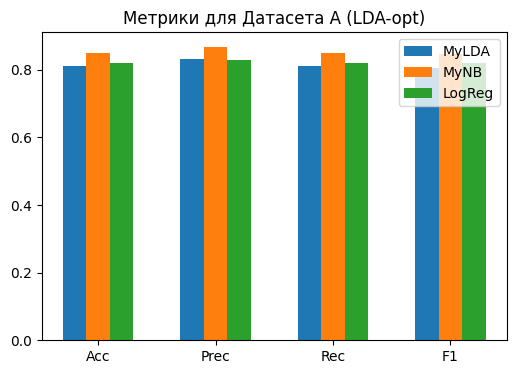


Датасет B (NB-opt)
MyLDA Confusion Matrix:
[[38 10]
 [14 38]]
MyNB Confusion Matrix:
[[48  0]
 [ 0 52]]
LogReg Confusion Matrix:
[[35 13]
 [15 37]]


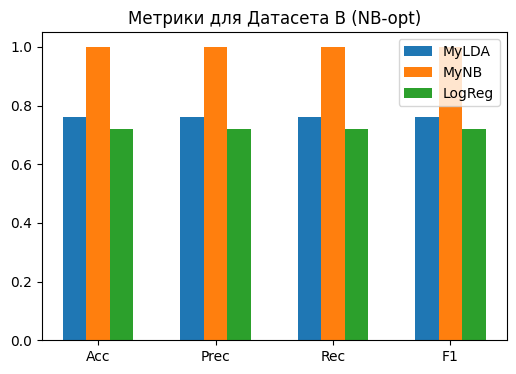


Датасет C (Сложный)
MyLDA Confusion Matrix:
[[37  8]
 [19 36]]
MyNB Confusion Matrix:
[[44  1]
 [ 1 54]]
LogReg Confusion Matrix:
[[37  8]
 [15 40]]


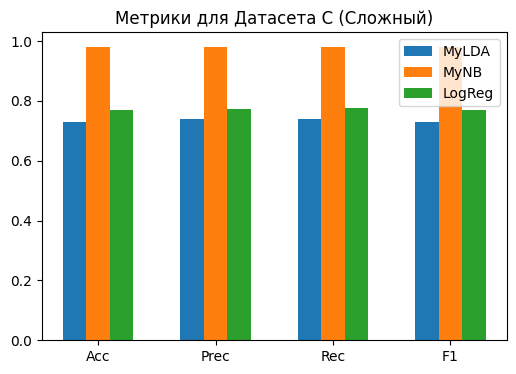

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as MyLDA
from sklearn.naive_bayes import GaussianNB as MyNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X_A, y_A = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=2, random_state=42)
X_B, y_B = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=0, random_state=42)
X_B[y_B == 1] *= 3.0

X_C, y_C = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=2, flip_y=0.05, random_state=42)
X_C[y_C == 1] *= 2.0

datasets = {'A (LDA-opt)': (X_A, y_A), 'B (NB-opt)': (X_B, y_B), 'C (Сложный)': (X_C, y_C)}
models = {'MyLDA': MyLDA(), 'MyNB': MyNB(), 'LogReg': LogisticRegression()}
metrics = [accuracy_score, precision_score, recall_score, f1_score]

for name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scores = {m: [] for m in models}

    print(f"\nДатасет {name}")
    for m_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        scores[m_name] = [metrics[0](y_test, preds)] + [f(y_test, preds, average='macro') for f in metrics[1:]]
        print(f"{m_name} Confusion Matrix:\n{confusion_matrix(y_test, preds)}")


    plt.figure(figsize=(6, 4))
    x = np.arange(4)
    for i, (m_name, vals) in enumerate(scores.items()):
        plt.bar(x + i*0.2, vals, 0.2, label=m_name)
    plt.title(f"Метрики для Датасета {name}")
    plt.xticks(x + 0.2, ['Acc', 'Prec', 'Rec', 'F1'])
    plt.legend()
    plt.show()

1. Где LDA лучше NB?
На датасете A. Там есть n_redundant=2 — признаки коррелированы. LDA учитывает корреляцию через ковариационную матрицу, а NB предполагает независимость и игнорирует её. Поэтому NB работает хуже.

2. Где NB лучше?
На датасете B. Там n_redundant=0 — признаки независимы. Это ровно предположение NB, поэтому он оптимален. Плюс NB оценивает меньше параметров — меньше переобучения.

3. Как влияет размерность?
LDA: параметров O(d2) — при большой размерности и малой выборке переобучается.

NB: параметров O(d) — устойчивее к росту размерности.

4. Почему обе падают на C?
Три причины сразу:

Шум 5% в метках — accuracy выше 95% невозможна в принципе.

Коррелированные признаки — NB не справляется.

Разные ковариации — LDA не справляется.

LogReg выигрывает — у него меньше предположений.